In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().cwd().parents[1]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = c:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [ ]:
from src.utils.montage_processing import *
from src.utils.parse_files import *
filename_colors = r"../../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values

positions = get_topo_positions(CED_FILE)

In [4]:
folder = r"..\..\data\exp\datasets_offBCI"
filenames = os.listdir(folder)
filenames = np.asarray([filename for filename in filenames if filename.find("SOUND.mat") != -1])

def get_session_n(filename):
    return int(filename[filename.find("_")+1: filename.find("__")])

fl_dict = {}
for filename in filenames:
    fl_dict[str(filename)] = get_orig_name(os.path.join(folder, filename))

def get_session_subject_corr(fl_dict):
    session_dict = {}
    for session, record in zip(fl_dict.keys(), fl_dict.values()):
        session_dict[record[record.find("_")+1:record.find("_")+5]] = session[session.find("_")+1:session.find("__")]
    return session_dict
session_dict = get_session_subject_corr(fl_dict)
session_dict

{'18EK': '102',
 '01AV': '63',
 '02NS': '65',
 '07IK': '71',
 '14AL': '77',
 '04KK': '79',
 '08EN': '80',
 '12VD': '88',
 '15SZ': '93',
 '19IT': '94',
 '05UB': '96'}

In [5]:
fn = os.path.join(folder, filenames[0])

def get_epochs(subj, cond, spot, filenames):
    session_id = session_dict[subj] 
    epochs = []
    labels = []
    for filename in [fn for fn in filenames if fn.find(str(session_id)) != -1]:
        orig = get_orig_name(os.path.join(folder, filename))
        if orig.find(cond) != -1: # and orig.find(spot) != -1:
            print("---", orig, "---", filename, "---")
            tvec, epoch, lab = get_data(os.path.join(folder, filename))
            epochs.append(epoch)
            labels.extend(lab)
    epochs = np.concat(epochs, axis=1)
    labels = np.asarray(labels)
    return epochs, labels, tvec

def baseline_correction(epoch, tvec, from_ms=-100, to_ms=-50):
    baseline = np.mean(epoch[:, np.where((tvec>=from_ms) & (tvec<=to_ms))])
    return epoch - baseline

from scipy.stats import trim_mean
def get_teps(labels, epochs, tvec):
    rest_mask = np.where(labels[:, 1] == 1)[0]
    mi_mask = np.where(labels[:, 0] == 1)[0]

    epochs_baseline_corr = np.asarray([baseline_correction(epochs[:, i, :], tvec) for i in range(epochs.shape[1])])
    epochs_baseline_corr = np.swapaxes(epochs_baseline_corr, 0, 1)

    TEPs_rest = trim_mean(epochs_baseline_corr[:, rest_mask, :], 0.1, axis=1 )
    TEPs_MI = trim_mean(epochs_baseline_corr[:, mi_mask,  :], 0.1, axis=1)
    return TEPs_rest, TEPs_MI

In [6]:
subj = "01AV" 
cond = "offBCI" 
spot = "M1_AP"

TEPs_rest, TEPs_MI = [], []
for subj in session_dict.keys()[:4]:
    epochs, labels, tvec  = get_epochs(subj, cond, spot, filenames)
    print(epochs.shape, labels.shape)
    rest, mi = get_teps(labels, epochs, tvec)
    TEPs_rest.append(rest)
    TEPs_MI.append(mi)

--- 11_18EK_M1_PA_34MSO_offBCI.hdf5 --- session_102__set_12__cleaned_SOUND.mat ---
--- 12_18EK_M1_PA_34MSO_offBCI.hdf5 --- session_102__set_13__cleaned_SOUND.mat ---
(64, 346, 4001) (346, 2)
--- 13_01AV_M1_AP_42MSO_offBCI.hdf5 --- session_63__set_13__cleaned_SOUND.mat ---
--- 14_01AV_M1_AP_42MSO_offBCI.hdf5 --- session_63__set_14__cleaned_SOUND.mat ---
(64, 340, 4001) (340, 2)
--- 12_02NS_M1_AP_54MSO_offBCI.hdf5 --- session_65__set_13__cleaned_SOUND.mat ---
--- 13_02NS_M1_AP_54MSO_offBCI.hdf5 --- session_65__set_14__cleaned_SOUND.mat ---
(64, 243, 4001) (243, 2)
--- 12_07IK_M1_AP_50MSO_offBCI.hdf5 --- session_71__set_13__cleaned_SOUND.mat ---
--- 13_07IK_M1_AP_50MSO_offBCI.hdf5 --- session_71__set_14__cleaned_SOUND.mat ---
(64, 336, 4001) (336, 2)
--- 13_14AL_M1_AP_53MSO_offBCI.hdf5 --- session_77__set_13__cleaned_SOUND.mat ---
--- 14_14AL_M1_AP_53MSO_offBCI.hdf5 --- session_77__set_14__cleaned_SOUND.mat ---
(64, 299, 4001) (299, 2)
--- 12_04KK_M1_AP_36MSO_offBCI.hdf5 --- session_79__s

In [7]:
TEPs_rest = np.asarray(TEPs_rest[1:])
TEPs_MI = np.asarray(TEPs_MI[1:])
TEPs_rest.shape, TEPs_MI.shape

((10, 64, 4001), (10, 64, 4001))

In [8]:
# усредняем условия внутри каждого испытуемого 
TEPs_subj = np.asarray([np.mean([rest, MI], axis=0) for rest, MI in zip(TEPs_rest, TEPs_MI)])
TEPs_subj.shape

(10, 64, 4001)

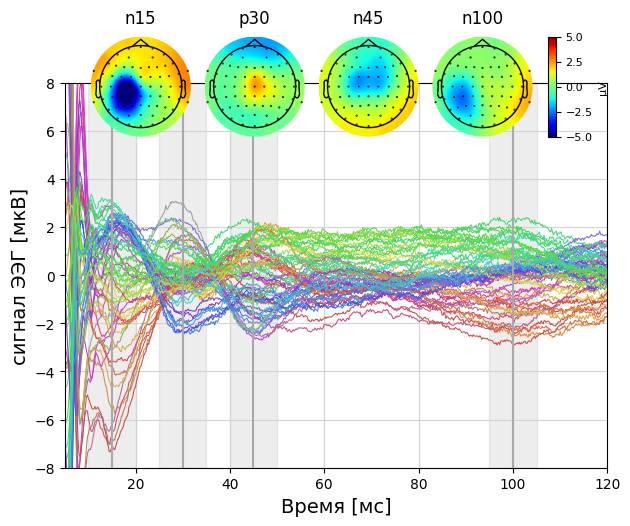

In [9]:
def plot_TEPs_with_topo(ax, TEPs, tmin=5, tmax=120, amp=10, comps = [15, 30, 45, 100]):

    comp_names = ["n15", "p30", "n45", "n100"]
    topo_windows = [(10, 25), (20, 38), (38, 55), (80, 120)]

    for color, TEP in zip(colors, TEPs): # начало движения
        ax.plot(tvec, TEP, color=color, linewidth=.75)
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    ax.set_xlabel("Время [мс]", fontsize=14)
    ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
    ax.grid(color="lightgrey")
    ax.axvline(0, color="black", linewidth=2)

    topo_size = 0.26
    topo_y = 0.86
    topo_xs = np.linspace(0.01, 0.64, len(topo_windows))

    t = tmin
    def get_mask(tlim, tvec):
        return np.where((tvec >= tlim[0]) & (tvec <= tlim[1]))[0]

    for topo_x, tlim, comp,name in zip(topo_xs, topo_windows, comps,comp_names):
        time_mask = get_mask([comp-5, comp+5], tvec)
        TEPs_topo = np.mean(TEPs[:, time_mask], axis=1)

        topo_ax = ax.inset_axes([topo_x, topo_y, topo_size, topo_size])
        max_value = 5
        im, _ = plot_topomap(
            TEPs_topo,
            positions,
            axes=topo_ax,
            ch_type="eeg",
            image_interp="cubic",
            size=5,
            show=False,
            contours=0,
            sphere=0.55,
            cmap="jet",
            extrapolate="head",
            vlim=(-max_value, max_value),
        )
        topo_ax.set_title(name, fontsize=12, y=1.05)

        ax.axvline(comp, color="darkgrey")
        a = 0.2
        ax.axvspan(comp-5, comp+5, alpha=a, color='darkgrey', zorder=1)

    cbar_ax = ax.inset_axes([0.89, topo_y, 0.015, topo_size])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("μV", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
TEPs = np.mean(TEPs_subj, axis=0)
plot_TEPs_with_topo(ax, TEPs, amp=8)

In [10]:
windows = {
    "N15":  (10, 25),
    "P30":  (25, 38),
    "N45":  (38, 55),
    "P60":  (55, 75),
    "N100": (85, 140),
}

for window in windows.values():
    def get_mask(tlim, tvec):
        return np.where((tvec >= tlim[0]) & (tvec <= tlim[1]))[0]
    channels = np.mean(TEPs[:, get_mask(window, tvec)], axis=1)
    ch_idx = np.argmax(channels)
    print(df["labels"][ch_idx])

FT10
Cz
TP10
P6
TP10


In [11]:
from __future__ import annotations

from collections.abc import Mapping, Sequence
from typing import Any, Literal

import mne
import numpy as np


def make_connected_roi(
    topography: Mapping[str, float] | np.ndarray,
    info: mne.Info,
    *,
    polarity: Literal["positive", "negative"],
    ch_names: Sequence[str] | None = None,
    allowed_channels: Sequence[str] | None = None,
    seed_channel: str | None = None,
    threshold_rel: float = 0.70,
    min_size: int = 3,
    max_size: int = 6,
    grow_to_min_size: bool = True,
    require_correct_polarity: bool = True,
) -> dict[str, Any]:
    """
    Создать пространственно связный ROI по топографии EEG-компонента.

    Алгоритм
    --------
    1. Для положительного компонента score = amplitude.
       Для отрицательного компонента score = -amplitude.
    2. Выбирается seed-электрод с максимальным score.
    3. Кластер выращивается только через соседние электроды.
    4. В основной кластер включаются электроды с:
           score >= threshold_rel * score_seed
    5. Размер ограничивается параметром max_size.
    6. При grow_to_min_size=True кластер может быть расширен до min_size
       лучшими соседями нужной полярности, даже если они ниже порога.

    Parameters
    ----------
    topography
        Значение амплитуды компонента для каждого электрода.

        Возможные варианты:
        - dict: {"C3": -4.1, "C1": -3.8, ...};
        - numpy-массив, тогда необходимо передать ch_names;
        - если длина массива совпадает с числом EEG-каналов в info,
          ch_names можно не передавать.

    info
        MNE Info с корректно заданным монтажом/координатами электродов.

    polarity
        "positive" для P-компонента или "negative" для N-компонента.

    ch_names
        Названия каналов в порядке значений массива topography.
        Для словаря не требуется.

    allowed_channels
        Ограничение области поиска. Например, для N15 можно разрешить
        только центрально-теменные электроды. Если None, используется
        вся EEG-сетка.

    seed_channel
        Заранее заданный начальный электрод. Если None, выбирается
        электрод с максимальным score.

    threshold_rel
        Относительный порог относительно seed:
            score >= threshold_rel * score_seed.
        Обычно разумно начинать с 0.70–0.80.

    min_size
        Минимальный желательный размер ROI.

    max_size
        Максимальный размер ROI.

    grow_to_min_size
        Если True, разрешить расширение до min_size электродами ниже
        основного порога, но только нужной полярности.

    require_correct_polarity
        Если True, кластер не создаётся, когда нет значений нужной
        полярности.

    Returns
    -------
    result : dict
        Основные поля:

        result["channels"]
            Электроды ROI в порядке добавления.

        result["seed"]
            Seed-электрод.

        result["detected"]
            Удалось ли выделить компонент нужной полярности.

        result["threshold"]
            Абсолютное значение применённого порога score.

        result["values"]
            Исходные амплитуды выбранных электродов.

        result["scores"]
            Амплитуды после приведения к нужной полярности.

        result["above_threshold"]
            Для каждого электрода: прошёл ли основной порог.

        result["status"]
            "ok", "expanded_below_threshold", "too_small" или
            "no_correct_polarity".
    """
    if polarity not in {"positive", "negative"}:
        raise ValueError(
            "polarity должна быть 'positive' или 'negative'."
        )

    if not 0 < threshold_rel <= 1:
        raise ValueError("threshold_rel должен находиться в интервале (0, 1].")

    if min_size < 1:
        raise ValueError("min_size должен быть не меньше 1.")

    if max_size < min_size:
        raise ValueError("max_size должен быть не меньше min_size.")

    # --------------------------------------------------------------
    # 1. Получаем матрицу соседства EEG-электродов
    # --------------------------------------------------------------
    adjacency, adjacency_names = mne.channels.find_ch_adjacency(
        info,
        ch_type="eeg",
    )

    adjacency_names = list(adjacency_names)
    adjacency = adjacency.tocsr(copy=True)

    # Убираем самосвязи, если они присутствуют.
    adjacency.setdiag(0)
    adjacency.eliminate_zeros()

    # --------------------------------------------------------------
    # 2. Сопоставляем топографию с порядком каналов adjacency
    # --------------------------------------------------------------
    if isinstance(topography, Mapping):
        value_by_channel = {
            str(name): float(value)
            for name, value in topography.items()
        }

    else:
        values_input = np.asarray(topography, dtype=float).squeeze()

        if values_input.ndim != 1:
            raise ValueError("topography должна быть одномерным массивом.")

        if ch_names is None:
            eeg_info = mne.pick_info(
                info,
                mne.pick_types(info, eeg=True, exclude=[]),
                copy=True,
            )
            inferred_names = eeg_info.ch_names

            if len(values_input) != len(inferred_names):
                raise ValueError(
                    "Нельзя определить соответствие каналов. "
                    "Передайте ch_names явно."
                )

            ch_names = inferred_names

        if len(values_input) != len(ch_names):
            raise ValueError(
                "Длина topography не совпадает с длиной ch_names."
            )

        value_by_channel = dict(zip(ch_names, values_input))

    values = np.array(
        [
            value_by_channel.get(name, np.nan)
            for name in adjacency_names
        ],
        dtype=float,
    )

    # --------------------------------------------------------------
    # 3. Ограничиваем разрешённую область поиска
    # --------------------------------------------------------------
    if allowed_channels is None:
        allowed_mask = np.ones(len(adjacency_names), dtype=bool)
    else:
        allowed_set = set(allowed_channels)
        allowed_mask = np.array(
            [name in allowed_set for name in adjacency_names],
            dtype=bool,
        )

        found_allowed = [
            name for name in adjacency_names
            if name in allowed_set
        ]

        if not found_allowed:
            raise ValueError(
                "Ни один allowed_channel не найден среди EEG-каналов."
            )

    allowed_mask &= np.isfinite(values)

    # --------------------------------------------------------------
    # 4. Приводим обе полярности к одной шкале
    # --------------------------------------------------------------
    polarity_sign = 1.0 if polarity == "positive" else -1.0
    scores = polarity_sign * values

    valid_indices = np.flatnonzero(allowed_mask)

    if len(valid_indices) == 0:
        raise ValueError(
            "После применения allowed_channels не осталось валидных каналов."
        )

    # --------------------------------------------------------------
    # 5. Выбираем seed
    # --------------------------------------------------------------
    if seed_channel is None:
        seed_idx = valid_indices[
            np.nanargmax(scores[valid_indices])
        ]
    else:
        if seed_channel not in adjacency_names:
            raise ValueError(
                f"Seed-канал {seed_channel!r} отсутствует в adjacency."
            )

        seed_idx = adjacency_names.index(seed_channel)

        if not allowed_mask[seed_idx]:
            raise ValueError(
                f"Seed-канал {seed_channel!r} не входит "
                "в allowed_channels или содержит NaN."
            )

    seed_score = float(scores[seed_idx])

    # Если для N-компонента нет отрицательной амплитуды или
    # для P-компонента нет положительной амплитуды.
    if require_correct_polarity and seed_score <= 0:
        return {
            "channels": [],
            "indices": [],
            "seed": adjacency_names[seed_idx],
            "detected": False,
            "threshold": np.nan,
            "values": {},
            "scores": {},
            "above_threshold": {},
            "status": "no_correct_polarity",
        }

    threshold = threshold_rel * seed_score

    # --------------------------------------------------------------
    # Вспомогательная функция: соседи электрода
    # --------------------------------------------------------------
    def get_neighbors(channel_idx: int) -> set[int]:
        neighbors = set(adjacency.getrow(channel_idx).indices)
        return {
            idx
            for idx in neighbors
            if allowed_mask[idx]
        }

    # --------------------------------------------------------------
    # 6. Выращиваем связный кластер
    # --------------------------------------------------------------
    selected = [seed_idx]
    selected_set = {seed_idx}

    frontier = get_neighbors(seed_idx) - selected_set

    while frontier and len(selected) < max_size:
        # Кандидаты, прошедшие основной порог.
        valid_frontier = [
            idx
            for idx in frontier
            if scores[idx] >= threshold
        ]

        if not valid_frontier:
            break

        # Добавляем лучшего пространственного соседа.
        next_idx = max(
            valid_frontier,
            key=lambda idx: scores[idx],
        )

        selected.append(next_idx)
        selected_set.add(next_idx)

        frontier.remove(next_idx)
        frontier.update(
            get_neighbors(next_idx) - selected_set
        )

    n_above_threshold = len(selected)

    # --------------------------------------------------------------
    # 7. При необходимости расширяем до минимального размера
    # --------------------------------------------------------------
    if grow_to_min_size:
        while frontier and len(selected) < min_size:
            # Добавляем только электроды правильной полярности.
            valid_frontier = [
                idx
                for idx in frontier
                if scores[idx] > 0
            ]

            if not valid_frontier:
                break

            next_idx = max(
                valid_frontier,
                key=lambda idx: scores[idx],
            )

            selected.append(next_idx)
            selected_set.add(next_idx)

            frontier.remove(next_idx)
            frontier.update(
                get_neighbors(next_idx) - selected_set
            )

    # --------------------------------------------------------------
    # 8. Формируем результат
    # --------------------------------------------------------------
    selected_names = [
        adjacency_names[idx]
        for idx in selected
    ]

    if len(selected) < min_size:
        status = "too_small"
    elif len(selected) > n_above_threshold:
        status = "expanded_below_threshold"
    else:
        status = "ok"

    return {
        "channels": selected_names,
        "indices": selected,
        "seed": adjacency_names[seed_idx],
        "detected": True,
        "threshold": threshold,
        "threshold_rel": threshold_rel,
        "values": {
            adjacency_names[idx]: float(values[idx])
            for idx in selected
        },
        "scores": {
            adjacency_names[idx]: float(scores[idx])
            for idx in selected
        },
        "above_threshold": {
            adjacency_names[idx]: bool(scores[idx] >= threshold)
            for idx in selected
        },
        "status": status,
        "size": len(selected),
    }

In [40]:
pos_3d = np.concatenate([positions, np.zeros((len(positions), 1))], axis=1)

In [34]:
np.zeros((len(positions), 1)).shape, positions.shape

((64, 1), (64, 2))

In [43]:
TEPs.shape

for window in windows.values():
    def get_mask(tlim, tvec):
        return np.where((tvec >= tlim[0]) & (tvec <= tlim[1]))[0]
    channels = np.mean(TEPs[:, get_mask(window, tvec)], axis=1)
    
    topography_dict = dict(
        zip(df["labels"].values, channels)
    )

    n45_search_area = [
        "F3", "F1", "Fz", "F2", "F4",
        "FC5", "FC3", "FC1", "FCz", "FC2", "FC4", "FC6",
        "C3", "C1", "Cz", "C2", "C4",
    ]

    info = mne.create_info(
        ch_names=df["labels"].tolist(),
        sfreq=1000,
        ch_types="eeg",
    )

    channel_positions = {
        name: np.asarray(position+[0], dtype=float)
        for name, position in zip(df["labels"].tolist(), pos_3d)
    }

    montage = mne.channels.make_dig_montage(
        ch_pos=channel_positions,
        coord_frame="head",
    )
    
    info.set_montage(
        montage,
        match_case=False,
        on_missing="raise",
    )

    n45_roi = make_connected_roi(
        topography=topography_dict,
        info=info,
        polarity="negative",
        # allowed_channels=n45_search_area,
        threshold_rel=0.70,
        min_size=3,
        max_size=6,
    )

    print(n45_roi["channels"])
    print(n45_roi["seed"])
    print(n45_roi["status"])
    print(n45_roi["values"])
    break

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 64


AttributeError: 'csr_array' object has no attribute 'getrow'

In [21]:
positions

array([[-0.53,  0.  ],
       [-0.63, -0.21],
       [-0.43, -0.31],
       [-0.38, -0.14],
       [-0.63,  0.21],
       [-0.43,  0.31],
       [-0.38,  0.14],
       [-0.22,  0.26],
       [-0.22, -0.26],
       [-0.27,  0.  ],
       [-0.13, -0.13],
       [-0.16, -0.51],
       [-0.16,  0.51],
       [-0.13,  0.13],
       [ 0.  ,  0.25],
       [ 0.16,  0.51],
       [ 0.  ,  0.  ],
       [ 0.13,  0.13],
       [ 0.13, -0.13],
       [ 0.  , -0.25],
       [ 0.16, -0.51],
       [ 0.  , -0.53],
       [ 0.27,  0.  ],
       [ 0.22, -0.26],
       [ 0.22,  0.26],
       [ 0.38,  0.14],
       [ 0.43,  0.31],
       [ 0.63,  0.21],
       [ 0.38, -0.14],
       [ 0.43, -0.31],
       [ 0.53,  0.  ],
       [ 0.63, -0.21],
       [-0.51,  0.17],
       [-0.51, -0.17],
       [-0.31,  0.43],
       [-0.33,  0.28],
       [-0.4 ,  0.  ],
       [-0.26,  0.13],
       [-0.26, -0.13],
       [-0.33, -0.28],
       [-0.16, -0.39],
       [-0.31, -0.43],
       [-0.13,  0.  ],
       [-0.

In [16]:
df["labels"].tolist()

['T7',
 'TP9',
 'P7',
 'CP5',
 'FT9',
 'F7',
 'FC5',
 'F3',
 'P3',
 'C3',
 'CP1',
 'O1',
 'Fp1',
 'FC1',
 'Fz',
 'Fp2',
 'Cz',
 'FC2',
 'CP2',
 'Pz',
 'O2',
 'Oz',
 'C4',
 'P4',
 'F4',
 'FC6',
 'F8',
 'FT10',
 'CP6',
 'P8',
 'T8',
 'TP10',
 'FT7',
 'TP7',
 'AF7',
 'F5',
 'C5',
 'FC3',
 'CP3',
 'P5',
 'PO3',
 'PO7',
 'C1',
 'P1',
 'AF3',
 'F1',
 'AF4',
 'Fpz',
 'FCz',
 'F2',
 'CPz',
 'C2',
 'POz',
 'P2',
 'PO8',
 'PO4',
 'P6',
 'CP4',
 'FC4',
 'C6',
 'F6',
 'AF8',
 'FT8',
 'TP8']